Pretrained Models and Transfer Learning Project:
Benjamin Kwon: 009241284

Python:
v3.12.0

Dataset:
CIFAR-10

Tech:
Pytorch

In [3]:
# Import PyTorch and Detect GPU for hardware acceleration
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Load CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
# Inspect a single sample
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Class name:", train_dataset.classes[label])

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 32, 32])
Label: 6
Class name: frog


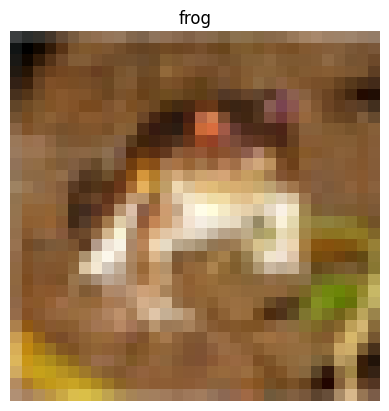

In [10]:
# Display the image
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

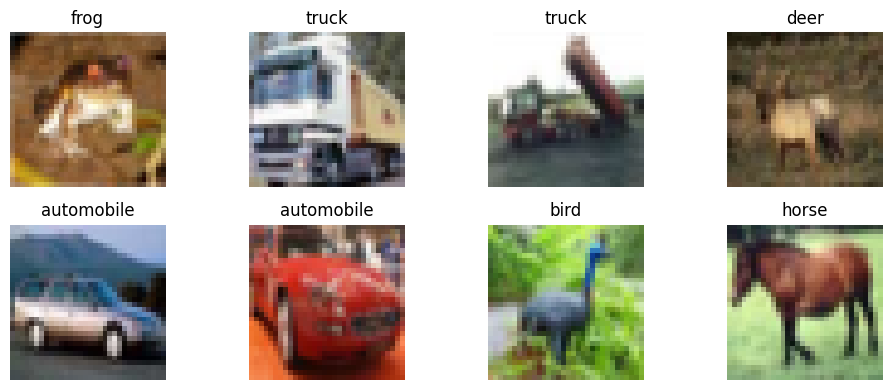

In [11]:
# Display multiple images and verify images by label
plt.figure(figsize=(10, 4))

for i in range(8):
    image, label = train_dataset[i]
    plt.subplot(2, 4, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(train_dataset.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Split the training dataset to train subset and validation subset
# train_dataset -> train_subset and val_subset; 9 to 1; 45000 to 5000
from torch.utils.data import random_split

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Manual seed of 42 for reproducibility
)

print("Train subset size:", len(train_subset))
print("Validation subset size:", len(val_subset))
print("Test dataset size:", len(test_dataset))

Train subset size: 45000
Validation subset size: 5000
Test dataset size: 10000
